# Análisis Multivariable — Admisiones de Posgrado

**Autor:** SCO

**Fecha:** 2026-08-19

**Descripción:**
Notebook 3 del Issue #3 "Análisis Exploratorio de Datos (EDA)". El Issue divide el EDA
en tres notebooks: (1) análisis univariable, (2) análisis bivariable y (3) análisis
**multivariable** (este notebook).

Este notebook estudia patrones, relaciones e interacciones entre **tres o más
atributos** a la vez, con foco en cómo se comporta `Chance of Admit` cuando se
consideran simultáneamente varias características del estudiante. Se trabaja sobre el
dataset preparado en el Issue #2 (`data/02_intermediate/Admission_Predict.parquet`).

El problema es de **regresión**: `Chance of Admit` es un target continuo acotado en
[0, 1]. Este notebook es exclusivamente **EDA descriptivo**: no se imputan nulos, no se
eliminan filas, duplicados ni outliers, no se escala, no se codifica, no se entrena
ningún modelo y no se hace PCA ni clustering.

**No se afirma causalidad** en ningún punto; se usa lenguaje de asociación y patrón.

## 📚 Import libraries

In [1]:
# librerías base para ciencia de datos
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 💾 Load data

Lectura **reproducible** e **inmutable** del dataset preparado: se localiza la raíz
del repositorio (buscando `pyproject.toml`) y se lee el Parquet tipado producido por
el Issue #2. No se modifica ni el Parquet ni el CSV RAW.

In [2]:
def find_repo_root(start: Path) -> Path:
    """Localiza la raíz del repositorio subiendo hasta encontrar `pyproject.toml`."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz del repositorio (pyproject.toml).")


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "02_intermediate" / "Admission_Predict.parquet"

admission_df = pd.read_parquet(DATA_PATH)

admission_df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## 👷 Preparación de datos y perfil del dataset

Este notebook **no transforma los datos**: es un análisis de lectura sobre el dataset
entregado por el Issue #2. El perfil completo ya fue documentado en los Notebooks 1
(univariable) y 2 (bivariable); aquí solo se recuerdan los elementos que afectan al
análisis multivariable.

### Perfil del dataset (resumen)

In [3]:
TARGET = "Chance of Admit"
PREDICTORS = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
]

print(f"Shape (filas, columnas): {admission_df.shape}")
print()
print("Nulos por columna:")
print(admission_df.isna().sum())
print()
n_dup = int(admission_df.duplicated().sum())
print(f"Filas duplicadas (conservando la primera): {n_dup} de {len(admission_df)}")

Shape (filas, columnas): (623, 8)

Nulos por columna:
GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

Filas duplicadas (conservando la primera): 152 de 623


El dataset tiene **623 filas y 8 columnas**. Elementos relevantes heredados de los
análisis anteriores:

- **Nulos**: 7 de 8 columnas tienen faltantes; `Chance of Admit` no. `Research` (29) y
  `TOEFL Score` (19) son las que más.
- **Duplicados**: 152 filas completamente duplicadas (24.4 %); **no se eliminan**.
- **Cómo se manejan los nulos aquí**: no se imputan ni se eliminan. Cada análisis
  multivariable usa **copias temporales con observaciones completas** de las columnas
  involucradas (complete-cases), por lo que **cada análisis tiene un `n` distinto**.
  `admission_df` permanece intacto.

## 📊 Análisis de resultados y conclusiones

### Helpers de visualización multivariable

Se definen funciones reutilizables para representar 3 o más variables a la vez:
scatter de dos predictores coloreado por el target, líneas de tendencia condicionadas
por una tercera variable, y tabla pivote de la media del target por cuartiles.

In [4]:
RESEARCH_LABELS = {0: "Sin experiencia", 1: "Con experiencia"}


def add_labels(data: pd.DataFrame) -> pd.DataFrame:
    """Devuelve una copia con `Research` como categoría etiquetada (para leyendas)."""
    data = data.copy()
    data["Research"] = data["Research"].map(RESEARCH_LABELS).astype("category")
    return data


def scatter_gradient(x_col: str, y_col: str) -> None:
    """Scatter de dos predictores coloreado por el target (3 variables)."""
    data = admission_df[[x_col, y_col, TARGET]].dropna()
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(
        data=data, x=x_col, y=y_col, hue=TARGET, palette="viridis", alpha=0.7, s=18, ax=ax
    )
    ax.set_title(f"{x_col} y {y_col}, coloreado por {TARGET}")
    fig.tight_layout()
    plt.show()


def lmplot_interaction(x_col: str, hue_col: str) -> None:
    """Líneas de tendencia del target vs x_col, separadas por hue_col (interacción visual)."""
    data = admission_df[[x_col, TARGET, hue_col]].dropna().copy()
    if hue_col == "Research":
        data = add_labels(data)
    else:
        data[hue_col] = data[hue_col].astype(int).astype(str)
    sns.lmplot(
        data=data,
        x=x_col,
        y=TARGET,
        hue=hue_col,
        scatter_kws={"alpha": 0.4, "s": 15},
        height=5,
    )
    plt.show()


def surface_pivots(x_col: str, y_col: str, q: int = 4) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Medias y conteos del target por cuartiles de dos predictores."""
    data = admission_df[[x_col, y_col, TARGET]].dropna().copy()
    labels = [f"Q{i}" for i in range(1, q + 1)]
    data[f"{x_col} q"] = pd.qcut(data[x_col], q, labels=labels)
    data[f"{y_col} q"] = pd.qcut(data[y_col], q, labels=labels)
    index = f"{y_col} q"
    columns = f"{x_col} q"
    means = data.pivot_table(index=index, columns=columns, values=TARGET, aggfunc="mean")
    counts = data.pivot_table(index=index, columns=columns, values=TARGET, aggfunc="count")
    return means, counts

### 1. Bloque académico (CGPA, GRE, TOEFL) + target

El análisis bivariable identificó un bloque de predictores académicos muy asociados
entre sí y con el target. Aquí se estudian **conjuntamente** para ver el patrón global
y si `Research` lo modifica. Un **pairplot** muestra todas las relaciones por pares a la
vez, coloreando por `Research`.

Observaciones completas (sin nulos en las 5 columnas): 569


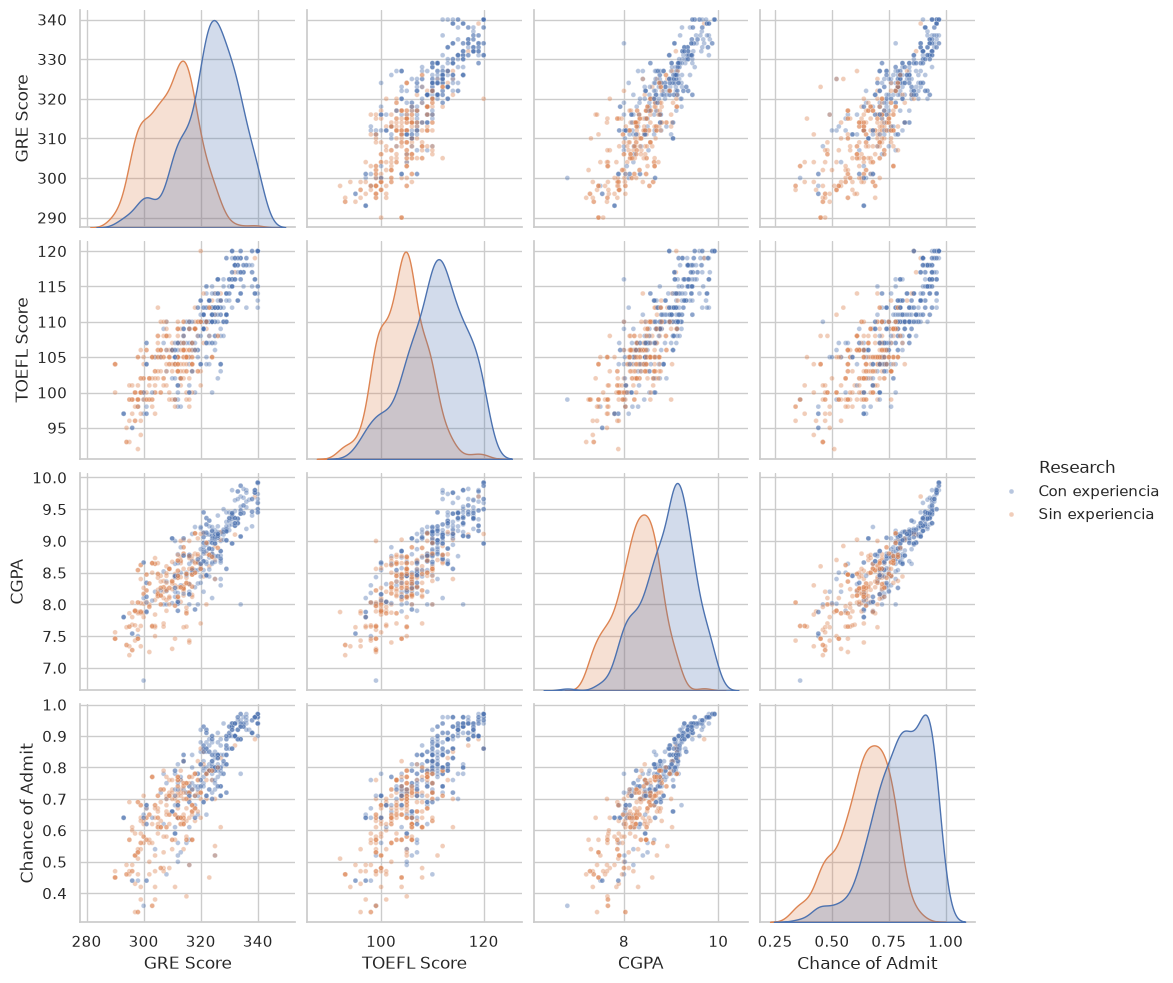

In [5]:
academic = admission_df[["GRE Score", "TOEFL Score", "CGPA", TARGET, "Research"]].dropna()
academic = add_labels(academic)

print(f"Observaciones completas (sin nulos en las 5 columnas): {len(academic)}")

sns.pairplot(
    academic,
    vars=["GRE Score", "TOEFL Score", "CGPA", TARGET],
    hue="Research",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 12},
)
plt.show()

**Lectura del pairplot** (n = 569 observaciones completas):

- Las diagonales muestran distribuciones casi simétricas para las cuatro variables.
- Los paneles fuera de la diagonal (`GRE`–`TOEFL`, `GRE`–`CGPA`, `TOEFL`–`CGPA`) muestran
  nubes **muy compactas y crecientes**: los tres puntajes se mueven juntos, evidencia
  visual de **redundancia** dentro del bloque académico.
- Los paneles de cada predictor contra `Chance of Admit` muestran un **gradiente
  positivo** claro.
- Coloreando por `Research`, los puntos con experiencia (naranja) tienden a ubicarse en
  la zona **superior-derecha** (GRE/TOEFL/CGPA altos). Esto sugiere que los estudiantes
  con experiencia en investigación tienen en promedio un **perfil académico más fuerte**,
  lo que podría explicar parte de su mayor `Chance of Admit` observada en el bivariable
  (posible **confusión**, no causalidad).

### 2. Perfil académico + target (dos predictores simultáneos)

A continuación se visualiza cómo varía el target cuando se consideran **dos predictores
a la vez**, coloreando los puntos por `Chance of Admit`. No basta la correlación: aquí
se observa el **gradiente del target sobre el plano** formado por cada par.

#### 2.1 `CGPA` + `GRE Score` → target

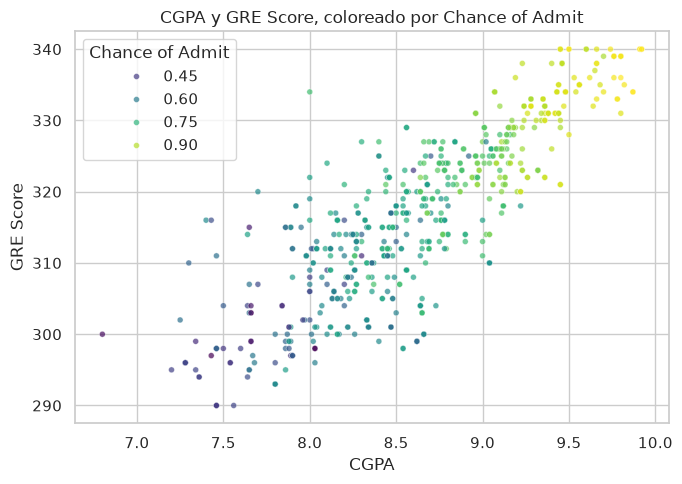

In [6]:
scatter_gradient("CGPA", "GRE Score")

El gradiente de color sigue la **diagonal**: CGPA y GRE bajos se asocian a valores
oscuros (target bajo) y la combinación de ambos altos, a valores claros (target alto).
Los puntos con `Chance of Admit` alto se concentran en la esquina superior-derecha. Aun
así, hay dispersión: combinaciones similares de CGPA+GRE pueden tener targets distintos,
lo que indica que **otras variables también aportan información**.

#### 2.2 `GRE Score` + `TOEFL Score` → target

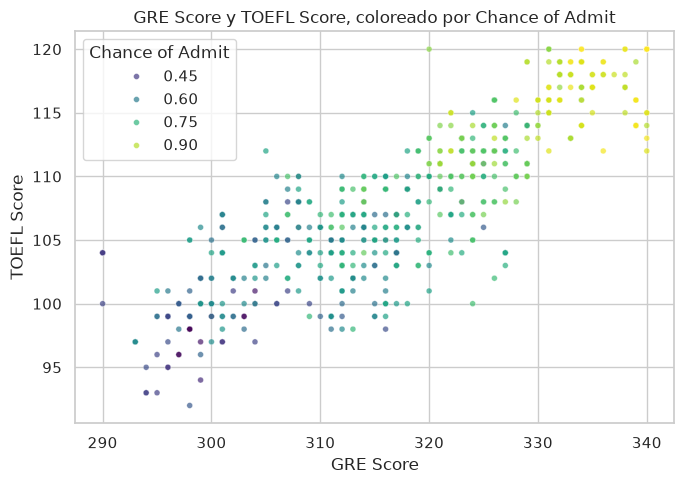

In [7]:
scatter_gradient("GRE Score", "TOEFL Score")

El gradiente es parecido y muy alineado con la diagonal GRE–TOEFL. Como ambos están
muy correlacionados (~0.85), el color cambia principalmente a lo largo de esa diagonal
y **no añaden direcciones de variación independientes**: combinaciones altas de GRE y
TOEFL implican target alto, pero la información que aporta TOEFL dada GRE es limitada.

#### 2.3 `CGPA` + `TOEFL Score` → target

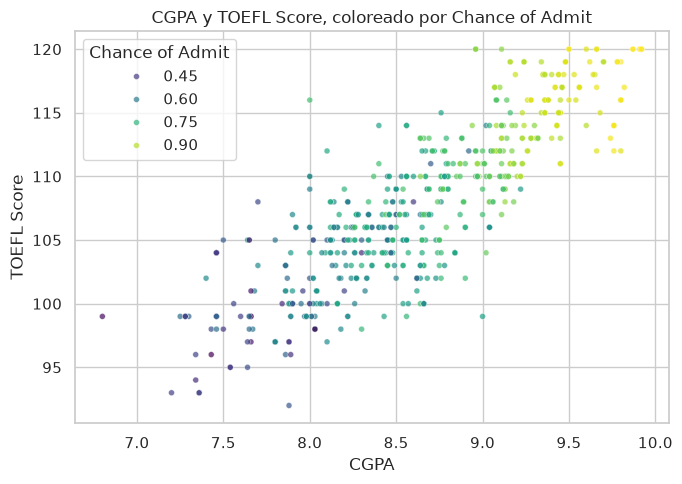

In [8]:
scatter_gradient("CGPA", "TOEFL Score")

Mismo patrón: gradiente positivo a lo largo de la diagonal CGPA–TOEFL. En conjunto,
las tres combinaciones del bloque académico muestran que el target **crece de forma
monótona con el perfil académico**, y que los tres predictores aportan información
**solapada** (redundante), no complementaria.

### 3. Variables académicas + variables de perfil (Research, University Rating)

Se estudian combinaciones seleccionadas con sentido analítico: cómo `Research` y
`University Rating` se relacionan con el vínculo entre `CGPA`/`GRE` y el target.

#### 3.1 `CGPA` + `Research` → target (¿difiere la pendiente?)

Se separa la relación CGPA→target por `Research` con líneas de tendencia. Si las líneas
fueran muy distintas en pendiente, habría evidencia visual de interacción.

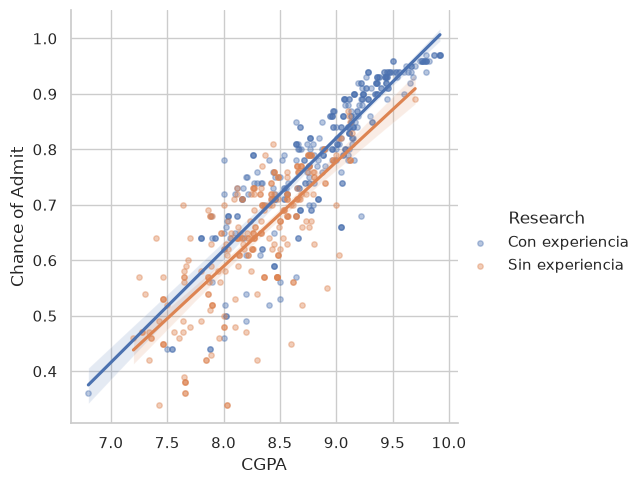

In [9]:
lmplot_interaction("CGPA", "Research")

In [10]:
data = admission_df[["CGPA", "Research", TARGET]].dropna().copy()
data["CGPA q"] = pd.qcut(data["CGPA"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
data.pivot_table(index="CGPA q", columns="Research", values=TARGET, aggfunc="mean").round(4)

Research,0,1
CGPA q,,
Q1,0.5542,0.6186
Q2,0.6697,0.7102
Q3,0.7433,0.7900
Q4,0.8243,0.9073


La media del target por cuartil de CGPA es **mayor para `Research = 1` en cada
cuartil**, y las dos líneas de tendencia tienen **pendientes similares** (casi
paralelas): el patrón es más compatible con un **desplazamiento** de `Research` que con
una interacción fuerte (la pendiente CGPA→target no cambia drásticamente). Además, los
grupos ocupan rangos de CGPA distintos (los de `Research = 1` se concentran en CGPA
altos), lo que refuerza la idea de **confusión** vista en el pairplot. No se afirma
interacción formal; habría que verificarla con un modelo.

#### 3.2 `CGPA` + `University Rating` → target

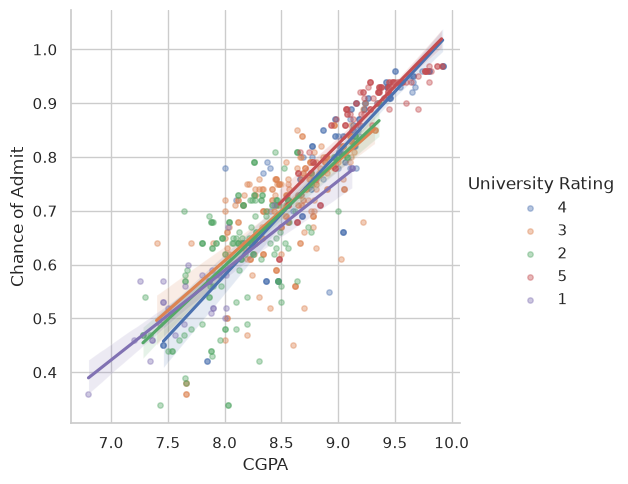

In [11]:
lmplot_interaction("CGPA", "University Rating")

A mayor rating, la línea de tendencia se desplaza hacia **targets más altos** para un
mismo CGPA, con pendientes parecidas. Es decir, el rating añade un nivel adicional al
CGPA: dos estudiantes con el mismo CGPA pero distinto rating tienden a tener distinto
`Chance of Admit`. Esto sugiere que `University Rating` aporta información **más allá**
del CGPA (complementaria).

#### 3.3 `University Rating` + `Research` → target

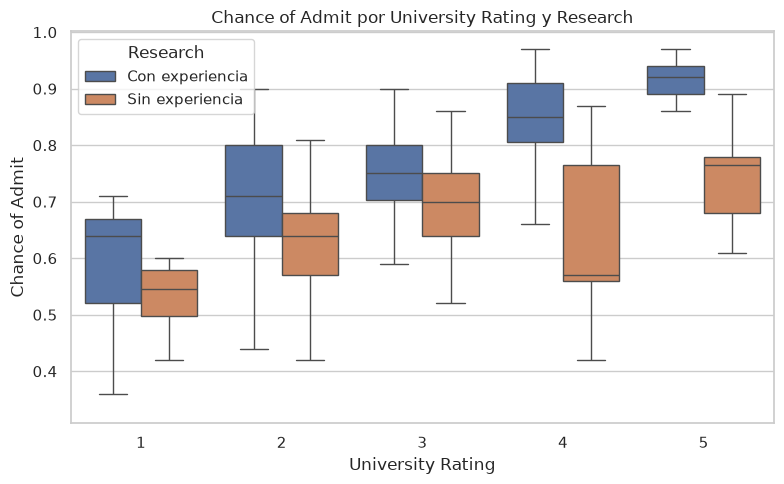

In [12]:
data = admission_df[["University Rating", "Research", TARGET]].dropna()
data = add_labels(data)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x="University Rating", y=TARGET, hue="Research", fliersize=0, ax=ax)
ax.set_title("Chance of Admit por University Rating y Research")
ax.set_xlabel("University Rating")
ax.set_ylabel("Chance of Admit")
ax.legend(title="Research")
fig.tight_layout()
plt.show()

In [13]:
data = admission_df[["University Rating", "Research", TARGET]].dropna()
data.pivot_table(
    index="University Rating", columns="Research", values=TARGET, aggfunc="mean"
).round(4)

Research,0,1
University Rating,,
1,0.5557,0.5800
2,0.6126,0.6930
3,0.6806,0.7426
4,0.6422,0.8522
5,0.7335,0.9087


Dentro de cada rating, la mediana del target es mayor para `Research = 1`, pero la
**diferencia no es uniforme**: es pequeña en ratings bajos (1–3) y mayor en ratings
altos (4–5). Esto es un **patrón compatible con una posible interacción** entre
`University Rating` y `Research` (el efecto de Research podría depender del rating), que
debería verificarse con modelamiento posterior. Los tamaños de grupo son muy desiguales
en los extremos (p. ej. rating 1 tiene muy pocos `Research = 1`), lo que limita la
lectura.

### 4. Redundancia / multicolinealidad del bloque académico

El bivariable ya detectó correlaciones altas entre `GRE`, `TOEFL` y `CGPA` (~0.84) y
entre `SOP` y `LOR` (~0.74). Aquí se profundiza con la matriz de correlación (evidencia
complementaria) y una visualización conjunta de tres variables.

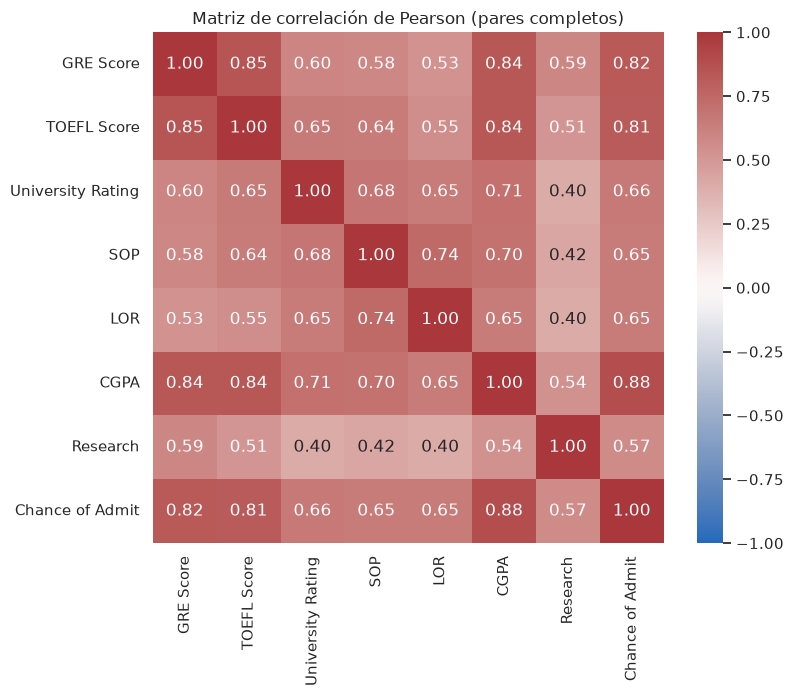

In [14]:
corr_matrix = admission_df[[*PREDICTORS, TARGET]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Matriz de correlación de Pearson (pares completos)")
fig.tight_layout()
plt.show()

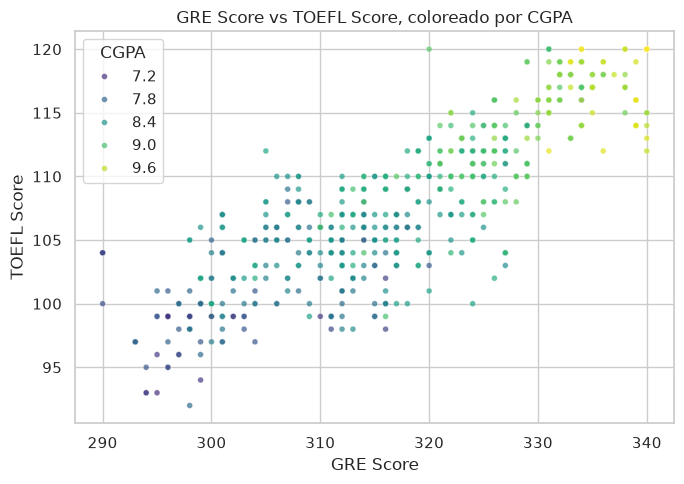

In [15]:
sub = admission_df[["GRE Score", "TOEFL Score", "CGPA"]].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=sub, x="GRE Score", y="TOEFL Score", hue="CGPA", palette="viridis", alpha=0.7, s=18, ax=ax
)
ax.set_title("GRE Score vs TOEFL Score, coloreado por CGPA")
fig.tight_layout()
plt.show()

La matriz de correlación **resume asociaciones por pares** (cada celda es una
correlación bivariable) y funciona como **evidencia complementaria**; no es por sí misma
una visualización de una relación multivariable. Confirma el bloque `GRE`–`TOEFL`–`CGPA`
(~0.84) y `SOP`–`LOR` (~0.74). El scatter `GRE` vs `TOEFL` coloreado por `CGPA` muestra
que **el CGPA también crece a lo largo de la diagonal** GRE–TOEFL: las tres variables se
alinean en una misma dirección, por lo que **gran parte de su información es redundante**.
Un modelo futuro probablemente no ganaría mucha precisión usando las tres a la vez; esto
se decidirá en modelamiento (p. ej. regularización o selección de variables), **no
aquí**.

### 5. Superficie del target (evidencia para heurística)

Para evaluar conceptualmente una futura heurística, se resume la **media** de
`Chance of Admit` por cuartiles de dos predictores (`CGPA` y `GRE`). Una superficie
monótona y ordenada sería evidencia de que una regla simple basada en estos puntajes
podría tener sentido.

Mínimo de la media del target: 0.546
Máximo de la media del target: 0.920



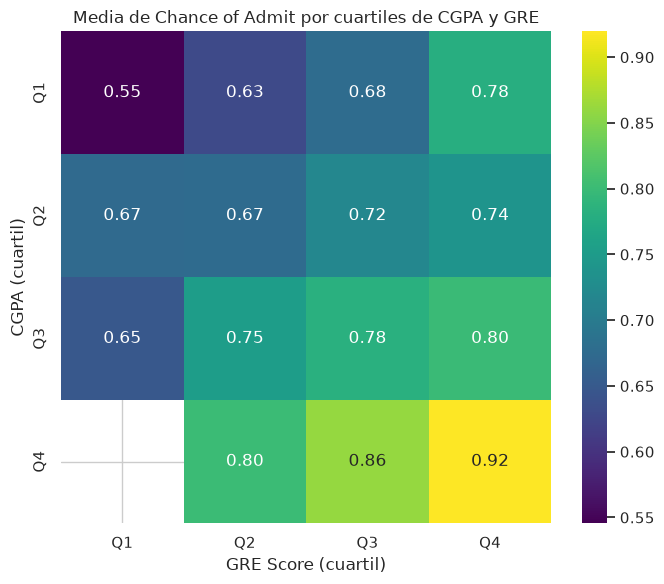

Observaciones por celda (n):


GRE Score q,Q1,Q2,Q3,Q4
CGPA q,,,,
Q1,105.0,41.0,7.0,1.0
Q2,51.0,71.0,31.0,4.0
Q3,4.0,39.0,86.0,22.0
Q4,NaN,1.0,38.0,109.0


In [16]:
surface, surface_counts = surface_pivots("GRE Score", "CGPA")

surface_min = surface.min().min()
surface_max = surface.max().max()
print(f"Mínimo de la media del target: {surface_min:.3f}")
print(f"Máximo de la media del target: {surface_max:.3f}")
print()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(surface, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_xlabel("GRE Score (cuartil)")
ax.set_ylabel("CGPA (cuartil)")
ax.set_title("Media de Chance of Admit por cuartiles de CGPA y GRE")
fig.tight_layout()
plt.show()

print("Observaciones por celda (n):")
surface_counts

La superficie muestra las **medias observadas** de `Chance of Admit` por combinación de
cuartiles de CGPA y GRE; **no son predicciones de un modelo** ni interpolaciones, sino el
promedio de los valores reales dentro de cada celda.

El gradiente global es **creciente**: la media sube desde el valor más bajo (esquina
inferior-izquierda, CGPA y GRE bajos) hasta el más alto (esquina superior-derecha, ambos
altos); los valores mínimo y máximo exactos se imprimen en la salida de la celda
anterior.

Sin embargo, la **tabla de conteos** (también en la celda anterior) advierte que el
gradiente **no es uniformemente confiable**: hay celdas con **muy pocas observaciones**
(dos celdas con n = 1) y una celda **sin observaciones** (cuartil alto de CGPA × cuartil
bajo de GRE, que queda como `NaN`). Las medias de esas celdas deben interpretarse con
cautela; la evidencia es sólida sobre todo en la diagonal (celdas con n alto).

Aun con esas reservas, el patrón general respalda que una **regla simple** de "a mayor
CGPA y GRE, mayor probabilidad" captura buena parte de la relación; la evaluación formal
corresponde a una etapa posterior.

## 💡 Propuestas e ideas

### Evaluación conceptual de una heurística

Los resultados multivariables sugieren que **sí existe evidencia suficiente para
considerar una heurística en una etapa posterior**, aunque **no se implementa ni se
valida aquí**:

- El bloque académico (`CGPA`, `GRE`, `TOEFL`) produce una **superficie monótona** del
  target, pero es **redundante**: una heurística podría basarse en uno o dos de ellos
  (p. ej. `CGPA` + `GRE`) sin perder mucha señal.
- `University Rating` parece **añadir información más allá del CGPA** (desplaza el
  target a un nivel distinto para el mismo CGPA).
- `Research` se asocia a un target mayor, pero parte de esa señal podría provenir del
  perfil académico más fuerte de esos estudiantes (**posible confusión**).

Estas observaciones apuntan a una heurística futura de tipo "puntaje compuesto"
(CGPA + GRE + ajuste por rating y research), pero su viabilidad y precisión deben
evaluarse formalmente en una etapa posterior.

### Implicaciones para Machine Learning (a resolver después)

Identificadas a partir del análisis, **sin implementarlas**:

- **Multicolinealidad / redundancia**: el bloque GRE–TOEFL–CGPA es altamente redundante;
  convendrá evaluar regularización o selección de variables.
- **Posibles interacciones**: `University Rating` × `Research` (y en menor medida
  `CGPA` × `Research`) muestran patrones compatibles con interacción; se podrían probar
  términos de interacción o modelos no lineales.
- **Posible confusión**: el efecto aparente de `Research` podría explicarse en parte por
  CGPA/GRE; un modelo multivariable lo aclarará.
- **Features derivadas**: un puntaje académico compuesto (CGPA+GRE) podría resumir el
  bloque redundante.
- **Escalado, imputación, deduplicación y encoding ordinal** siguen pendientes (ver
  Notebook 2).

### Conclusiones del análisis multivariable

**Hallazgos observados**

- El bloque `CGPA`–`GRE`–`TOEFL` forma un **gradiente académico monótono** con el target
  y es internamente **redundante** (las tres se alinean en una misma dirección).
- `University Rating` parece **complementar** al CGPA (desplaza el nivel del target para
  un mismo CGPA).
- `Research` se asocia a un target mayor, pero su señal se **solapa parcialmente** con la
  del perfil académico (posible confusión).
- Se observa un **patrón compatible con interacción** entre `University Rating` y
  `Research` (la diferencia Research sí/no no es uniforme entre ratings).

**Hipótesis (a verificar con modelamiento)**

- La mayor parte de la señal predictiva reside en el bloque académico; SOP y LOR aportan
  poco más allá de lo ya capturado.
- `Research` podría tener un efecto menor una vez controlado por CGPA/GRE.

**Decisiones que deberán tomarse posteriormente**

- Cómo tratar la multicolinealidad (regularización vs selección).
- Si incluir interacciones o un puntaje compuesto.
- Si deduplicar antes del split (por el riesgo de leakage).

**Limitaciones**

- Los 152 duplicados pueden **inflar** patrones y producir repeticiones excesivas en las
  visualizaciones (no se eliminaron).
- Los nulos hacen que cada análisis use un `n` distinto (569–610 observaciones completas).
- Las conclusiones de interacción son **visuales**, no pruebas estadísticas formales.
- Análisis observacional: no se establece causalidad.

## 📖 Referencias

- Notebook 1 (univariable): `notebooks/3-analysis/03.1-SCO_univariate_analysis-2026_08_19.ipynb`.
- Notebook 2 (bivariable): `notebooks/3-analysis/03.2-SCO_bivariate_analysis-2026_08_19.ipynb`.
- Issue #2 — *Exploración inicial de datos*:
  `notebooks/2-exploration/02.1-SCO_data_exploration-2026_08_19.ipynb`.
- `data/01_raw/Informacion.txt` — descripción del dataset y sus variables.
- Zapata, J. R. — *Análisis exploratorio de datos* (referencia del curso):
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/>.
- Documentación de pandas (`qcut`, `pivot_table`, `corr`) y seaborn (`pairplot`,
  `scatterplot`, `lmplot`, `boxplot`, `heatmap`).